In [2]:
import sys
import pathlib
sys.path.append(r"/home/vikhyat/rrt-experiments/PythonRobotics/PathPlanning/")

import matplotlib.pyplot as plt
import numpy as np
from RRT.rrt import RRT
from RRTStar.rrt_star import RRTStar
from time import time

In [3]:
def dist(a, b):
    return ((a[0]-b[0])**2+(a[1]-b[1])**2)**0.5

In [4]:
# ====Search Path with RRT====
obstacle_list = [
    (5, 5, 0.1),
    (3, 6, 0.2),
    (3, 8, 0.2),
    (3, 10, 0.2),
    (7, 5, 0.2),
    (9, 5, 0.2),
    (8, 10, 1),
    (6, 12, 1),
]

# Set Initial parameters

show_animation = False
expand_dis = 1
start = [0,0]
end = [6, 10]

# rrt = RRTStar(
#     start=start,
#     goal=end,
#     rand_area=[-2, 15],
#     obstacle_list=obstacle_list,
#     expand_dis=expand_dis, # max length of one RRT branch step
#     robot_radius=0.8,
#     max_iter=1000)

# Testing with RRT Star

In [5]:
history_obstacles = []
paths = []
for i in range(10):
	rrt = RRTStar(start=start,
						goal=end,
						rand_area=[-2, 15],
						obstacle_list=obstacle_list,
						expand_dis=expand_dis, # max length of one RRT branch step
						robot_radius=0.8,
						max_iter=1000)
	rrt.obstacle_list = obstacle_list + history_obstacles

	start_time = time()
	path = rrt.planning(animation=show_animation, verbose=False)
	print(time()-start_time, 'seconds', (': path not found' if path is None else ': path found'))

	if path is not None:
		history_obstacles += [(point[0],point[1],0.1) for point in path if (dist(point, start) > expand_dis*2) and (dist(point, end) > expand_dis*2)]
		paths.append(path)


In [6]:
# # Draw final path
rrt.obstacle_list = obstacle_list
# rrt.draw_graph()

##### Draw map
for (ox, oy, size) in rrt_star.obstacle_list:
	rrt_star.plot_circle(ox, oy, size)

if rrt_star.play_area is not None:
	plt.plot([rrt_star.play_area.xmin, rrt_star.play_area.xmax,
				rrt_star.play_area.xmax, rrt_star.play_area.xmin,
				rrt_star.play_area.xmin],
				[rrt_star.play_area.ymin, rrt_star.play_area.ymin,
				rrt_star.play_area.ymax, rrt_star.play_area.ymax,
				rrt_star.play_area.ymin],
				"-k")

plt.plot(rrt_star.start.x, rrt_star.start.y, "xr")
plt.plot(rrt_star.end.x, rrt_star.end.y, "xr")
plt.axis("equal")
plt.axis([rrt_star.min_rand, rrt_star.max_rand, rrt_star.min_rand, rrt_star.max_rand])
plt.grid(True)

###### Draw paths
for path_i, path in enumerate(paths):
	plt.plot([x for (x, y) in path], [y for (x, y) in path], '--', label=f'Path {path_i}')

plt.grid(True)
plt.gca().set_aspect('equal')
plt.legend()
plt.show()

# Testing with RRT

In [5]:
history_obstacles = []
paths = []
for i in range(10):
	rrt = RRT(start=start,
						goal=end,
						rand_area=[-2, 15],
						obstacle_list=obstacle_list,
						expand_dis=expand_dis, # max length of one RRT branch step
						robot_radius=0.8,
						max_iter=1000)
	rrt.obstacle_list = obstacle_list + history_obstacles

	start_time = time()
	path = rrt.planning(animation=show_animation)
	print(time()-start_time, 'seconds', (': path not found' if path is None else ': path found'))

	if path is not None:
		history_obstacles += [(point[0],point[1],0.1) for point in path if (dist(point, start) > expand_dis*2) and (dist(point, end) > expand_dis*2)]
		paths.append(path)


0.010264873504638672 seconds : path found
0.01967787742614746 seconds : path found
0.09175467491149902 seconds : path not found
0.0880434513092041 seconds : path not found
0.09021186828613281 seconds : path not found
0.11784482002258301 seconds : path not found
0.0814056396484375 seconds : path not found
0.08289361000061035 seconds : path not found
0.08331108093261719 seconds : path not found
0.07932591438293457 seconds : path not found


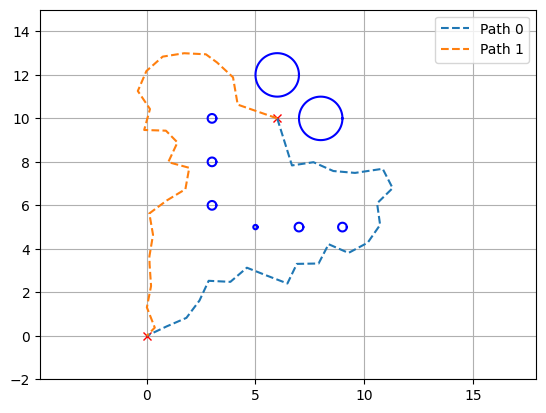

In [6]:
# # Draw final path
rrt.obstacle_list = obstacle_list
# rrt.draw_graph()

##### Draw map
for (ox, oy, size) in rrt.obstacle_list:
	rrt.plot_circle(ox, oy, size)

if rrt.play_area is not None:
	plt.plot([rrt.play_area.xmin, rrt.play_area.xmax,
				rrt.play_area.xmax, rrt.play_area.xmin,
				rrt.play_area.xmin],
				[rrt.play_area.ymin, rrt.play_area.ymin,
				rrt.play_area.ymax, rrt.play_area.ymax,
				rrt.play_area.ymin],
				"-k")

plt.plot(rrt.start.x, rrt.start.y, "xr")
plt.plot(rrt.end.x, rrt.end.y, "xr")
plt.axis("equal")
plt.axis([rrt.min_rand, rrt.max_rand, rrt.min_rand, rrt.max_rand])
plt.grid(True)

###### Draw paths
for path_i, path in enumerate(paths):
	plt.plot([x for (x, y) in path], [y for (x, y) in path], '--', label=f'Path {path_i}')

plt.grid(True)
plt.gca().set_aspect('equal')
plt.legend()
plt.show()